# The BFGS Method
**Course:** Advanced Numerical Optimization (20.IDI16) · **Mentor:** Prof. Marko Miladinović · **Author:** Elvir Muslić

This notebook accompanies the seminar paper *The BFGS Method*, a study project for the course. It has four parts.

1. **One update by hand (Section 4 of the paper).** The BFGS update (9) and its rank-two form (11), computed with NumPy on the paper's small example.
2. **BFGS in SciPy, and steepest descent (Section 5).** SciPy's `minimize(method="BFGS")` carries out Algorithm 1 of the paper; steepest descent, the baseline, is a short loop around SciPy's `line_search`.
3. **The Rosenbrock function (Section 6.1).** Both methods from $(-1.2, 1)$. The strong Wolfe conditions and the update are checked on SciPy's steps, and the error ratios show the two rates of convergence.
4. **Two test functions from Vilin (Section 6.2).** Both methods on TRIDIA and Raydan 1, two test functions of Vilin, the optimization framework of the course, with $n = 100$.

Run it in VS Code with the `.venv` kernel (Run All), or from this folder with `.venv/bin/jupyter nbconvert --to notebook --execute --inplace bfgs_project.ipynb`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import line_search, minimize, rosen, rosen_der, rosen_hess

C1, C2, GTOL = 1e-4, 0.9, 1e-5   # the constants of the Wolfe conditions (3)-(5), and the stopping test (12): ||g_k||_2 <= GTOL
OPTIONS = {"gtol": GTOL, "norm": 2, "c1": C1, "c2": C2, "return_all": True}   # the options of minimize(method="BFGS"), Section 2
Path("figures").mkdir(exist_ok=True)

def bfgs_update(H, s, y):
    # the BFGS update (9): H_{k+1} = V^T H V + rho s s^T, with rho = 1/(y^T s) and V = I - rho y s^T
    rho = 1 / (y @ s)
    V = np.eye(len(s)) - rho * np.outer(y, s)
    return V.T @ H @ V + rho * np.outer(s, s)

## 1. One update by hand (Section 4)
$H_k = I$, $s_k = (1, 0)$, $y_k = (2, 1)$. `bfgs_update` is the product form (9). The rank-two form (11) adds $s_k w_k^\top + w_k s_k^\top$ to $H_k$, with $w_k = \tfrac12\rho_k(1 + \rho_k\, y_k^\top H_k y_k)\, s_k - \rho_k H_k y_k$. Both forms give the matrix of Section 4 exactly. $H_{k+1} y_k - s_k = 0$ is the secant equation (7), and the two positive eigenvalues show that $H_{k+1}$ is positive definite (Theorem 3.1).

In [2]:
H, s, y = np.eye(2), np.array([1.0, 0.0]), np.array([2.0, 1.0])
H_9 = bfgs_update(H, s, y)                                   # product form (9)
rho = 1 / (y @ s)
w = 0.5 * rho * (1 + rho * (y @ H @ y)) * s - rho * H @ y
H_11 = H + np.outer(s, w) + np.outer(w, s)                   # rank-two form (11)
print(f"H_k+1 = {H_9.tolist()}, the same from (11): {np.array_equal(H_9, H_11)}, w = {w.tolist()}")
print(f"H_k+1 y - s = {(H_9 @ y - s).tolist()}, eigenvalues {np.linalg.eigvalsh(H_9).round(4).tolist()}")

H_k+1 = [[0.75, -0.5], [-0.5, 1.0]], the same from (11): True, w = [-0.125, -0.5]
H_k+1 y - s = [0.0, 0.0], eigenvalues [0.3596, 1.3904]


## 2. BFGS in SciPy, and steepest descent (Section 5)
`minimize(fun, x0, jac=grad, method="BFGS", options=...)` carries out Algorithm 1, with `fun` $= f$ and `jac` $= \nabla f$. In the paper's terms (read from SciPy's source, version 1.18.1):

- it starts from $H_0 = I$ and takes the direction $p_k = -H_k g_k$ (2);
- its line search, the Moré–Thuente search of MINPACK, returns a step length $\alpha_k$ that satisfies the strong Wolfe conditions (3) and (5), with the options `c1` and `c2` as $c_1$ and $c_2$ (SciPy's defaults, $10^{-4}$ and $0.9$, passed explicitly below); the first trial is $\min\bigl(1,\ 1.01 \cdot 2(f_k - f_{k-1})/g_k^\top p_k\bigr)$; if the search fails, SciPy tries Algorithms 3.5–3.6 of Nocedal and Wright, and if that returns no step either, the run stops with `res.success = False`;
- it updates $H_k$ by the product form (9);
- it stops when $\|g_k\| \le$ `gtol`; `norm=2` makes this the 2-norm of the stopping test (12) (SciPy's default norm is the largest absolute entry).

`OPTIONS`, set at the top, holds these options and `return_all=True`, which adds all iterates to the result as `res.allvecs`. The result `res` also holds the last iterate `res.x`, the number of iterations `res.nit`, the numbers of evaluations of $f$ and $\nabla f$, `res.nfev` and `res.njev`, the last gradient `res.jac` and the last $H_k$, `res.hess_inv`.

Steepest descent takes $p_k = -g_k$. SciPy's `line_search` is Algorithms 3.5–3.6 of Nocedal and Wright. It returns a step length that satisfies the strong Wolfe conditions with the same $c_1$ and $c_2$, the new $f$, and the new gradient (its last return value, which the docstring calls `new_slope`; SciPy's source returns the gradient vector there). Given $f$ at the previous iterate, it uses the same first trial as BFGS.

In [3]:
def steepest_descent(fun, grad, x0, maxiter=100_000):
    # p_k = -g_k with SciPy's strong Wolfe line search, until the stopping test (12); returns the iterates and f and g at each of them
    X, f, G = [x0], [fun(x0)], [grad(x0)]
    f_prev = f[0] + np.linalg.norm(G[0]) / 2                 # as in SciPy's BFGS, so the first trial is min(1, 1.01/||g_0||)
    while np.linalg.norm(G[-1]) > GTOL and len(X) <= maxiter:
        alpha, _, _, f_new, _, g_new = line_search(fun, grad, X[-1], -G[-1], G[-1], f[-1], f_prev, c1=C1, c2=C2)
        if g_new is None:
            raise RuntimeError("the line search found no step")
        f_prev = f[-1]
        X.append(X[-1] - alpha * G[-1])
        f.append(f_new)
        G.append(g_new)
    return np.array(X), np.array(f), np.array(G)

## 3. The Rosenbrock function (Section 6.1)
`rosen`, `rosen_der` and `rosen_hess` are SciPy's Rosenbrock function, $f(x) = 100(x_2 - x_1^2)^2 + (1 - x_1)^2$ for $n = 2$, its gradient and its Hessian. Both methods start from $x_0 = (-1.2, 1)$ and stop by (12); the minimizer is $x^* = (1, 1)$. For BFGS, $f$ and $g$ at the iterates `res.allvecs` are evaluated again.

In [4]:
x0, x_star = np.array([-1.2, 1.0]), np.array([1.0, 1.0])
res = minimize(rosen, x0, jac=rosen_der, method="BFGS", options=OPTIONS)
X = np.array(res.allvecs)
runs = {"BFGS": (X, np.array([rosen(x) for x in X]), np.array([rosen_der(x) for x in X])),
        "Steepest descent": steepest_descent(rosen, rosen_der, x0)}
print(f"SciPy: {res.message}")
for name, (X, f, G) in runs.items():
    print(f"{name}: {len(X) - 1} iterations, ||x - x*|| = {np.linalg.norm(X[-1] - x_star):.1e}")

SciPy: Optimization terminated successfully.
BFGS: 32 iterations, ||x - x*|| = 6.1e-08
Steepest descent: 10078 iterations, ||x - x*|| = 2.2e-05


**The theory on the run.** With $s_k = x_{k+1} - x_k = \alpha_k p_k$, the strong Wolfe condition (3) reads $f_{k+1} \le f_k + c_1\, g_k^\top s_k$, and (5), multiplied by $\alpha_k > 0$, reads $|g_{k+1}^\top s_k| \le c_2\, |g_k^\top s_k|$, so the iterates alone show whether they hold; Lemma 2.1 then gives $s_k^\top y_k > 0$.

SciPy keeps only its last $H_k$, so the loop below rebuilds the others: it applies `bfgs_update` from $H_0 = I$ along SciPy's steps (SciPy does not update after the last step) and compares the result with `res.hess_inv`. Each rebuilt $H_{k+1}$ is checked against Theorem 3.1 (secant equation, positive definiteness), and the step length is recovered as $\alpha_k = s_k^\top p_k / p_k^\top p_k$ with $p_k = -H_k g_k$.

In [5]:
for name, (X, f, G) in runs.items():
    S, Y = np.diff(X, axis=0), np.diff(G, axis=0)
    slope, new_slope = np.vecdot(G[:-1], S), np.vecdot(G[1:], S)   # g_k^T s_k and g_{k+1}^T s_k, one per step
    wolfe = np.all(f[1:] <= f[:-1] + C1 * slope) and np.all(np.abs(new_slope) <= C2 * np.abs(slope))
    print(f"{name}: (3) and (5) hold at all {len(S)} steps: {wolfe}; s^T y > 0 at all steps: {np.all(np.vecdot(S, Y) > 0)}")

X, f, G = runs["BFGS"]
H, alphas, secant, smallest = np.eye(2), [], 0.0, np.inf
for k in range(len(X) - 1):
    s, y, p = X[k + 1] - X[k], G[k + 1] - G[k], -H @ G[k]
    alphas.append(s @ p / (p @ p))                           # alpha_k, from s_k = alpha_k p_k
    if k < len(X) - 2:                                       # SciPy does not update after the last step
        H = bfgs_update(H, s, y)
        secant = max(secant, np.linalg.norm(H @ y - s) / np.linalg.norm(s))
        smallest = min(smallest, np.linalg.eigvalsh(H)[0])
unit = len(alphas) - 1 - max(k for k, a in enumerate(alphas) if abs(a - 1) > 1e-9)
print(f"rebuilt H against res.hess_inv: largest difference {np.abs(H - res.hess_inv).max() / np.abs(res.hess_inv).max():.1e}, relative to the largest entry")
print(f"every rebuilt H_k+1: ||H y - s|| / ||s|| <= {secant:.1e}, smallest eigenvalue {smallest:.1e}")
print(f"alpha_k = 1 (to rounding) at each of the last {unit} iterations")
print(f"res.hess_inv = {res.hess_inv.round(4).tolist()}, inverse Hessian at x* = {np.linalg.inv(rosen_hess(x_star)).round(4).tolist()}")

BFGS: (3) and (5) hold at all 32 steps: True; s^T y > 0 at all steps: True
Steepest descent: (3) and (5) hold at all 10078 steps: True; s^T y > 0 at all steps: True
rebuilt H against res.hess_inv: largest difference 4.4e-13, relative to the largest entry
every rebuilt H_k+1: ||H y - s|| / ||s|| <= 9.5e-14, smallest eigenvalue 4.7e-04
alpha_k = 1 (to rounding) at each of the last 10 iterations
res.hess_inv = [[0.5019, 1.0032], [1.0032, 2.0103]], inverse Hessian at x* = [[0.5, 1.0], [1.0, 2.005]]


**Rates.** The ratios $\|x_{k+1} - x^*\| / \|x_k - x^*\|$ of the last five steps. Superlinear convergence means that they tend to $0$; linear convergence, that they stay near a constant below $1$. For steepest descent that constant is compared with $(\kappa - 1)/(\kappa + 1)$, where $\kappa$ is the condition number of $\nabla^2 f(x^*)$.

In [6]:
for name, (X, f, G) in runs.items():
    e = np.linalg.norm(X - x_star, axis=1)
    q = e[1:] / e[:-1]
    print(f"{name}: last five ratios {q[-5:].round(4).tolist()}, geometric mean {np.exp(np.log(q[-5:]).mean()):.4f}")
kappa = np.linalg.cond(rosen_hess(x_star))
print(f"condition number of the Hessian at x*: {kappa:.0f}, (kappa - 1)/(kappa + 1) = {(kappa - 1) / (kappa + 1):.4f}")

BFGS: last five ratios [0.1463, 0.6, 0.0717, 0.0152, 0.0106], geometric mean 0.0633
Steepest descent: last five ratios [0.9995, 0.9985, 0.9995, 0.9985, 0.9995], geometric mean 0.9991
condition number of the Hessian at x*: 2508, (kappa - 1)/(kappa + 1) = 0.9992


**Figures.** Figure 1 of the paper shows the BFGS iterates over the contours of $f$; Figure 2 shows the gradient norm per iteration of both methods.

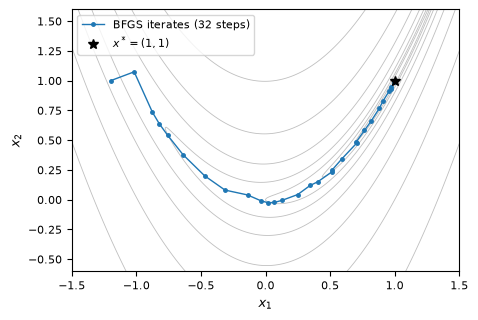

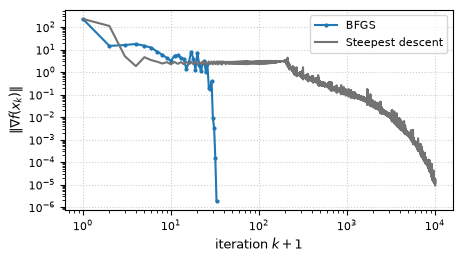

In [7]:
plt.rcParams.update({"font.size": 9, "axes.labelsize": 9, "legend.fontsize": 8, "xtick.labelsize": 8, "ytick.labelsize": 8, "pdf.fonttype": 42})
fig, ax = plt.subplots(figsize=(5.0, 3.4))
x1, x2 = np.meshgrid(np.linspace(-1.5, 1.5, 301), np.linspace(-0.6, 1.6, 301))
ax.contour(x1, x2, rosen(np.array([x1, x2])), levels=np.logspace(-1, 3, 9), colors="0.75", linewidths=0.6)
X = runs["BFGS"][0]
ax.plot(X[:, 0], X[:, 1], "o-", color="tab:blue", ms=2.5, lw=1.0, label=f"BFGS iterates ({len(X) - 1} steps)")
ax.plot(*x_star, "k*", ms=7, label="$x^* = (1, 1)$")
ax.set(xlabel="$x_1$", ylabel="$x_2$")
ax.legend(loc="upper left")
fig.savefig("figures/rosenbrock_path.pdf", bbox_inches="tight")

fig, ax = plt.subplots(figsize=(5.0, 2.6))
for (name, (X, f, G)), style, color in zip(runs.items(), ("o-", "-"), ("tab:blue", "0.45")):
    ax.loglog(np.arange(1, len(G) + 1), np.linalg.norm(G, axis=1), style, ms=2, color=color, label=name)
ax.set(xlabel="iteration $k + 1$", ylabel=r"$\|\nabla f(x_k)\|$")
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend()
fig.savefig("figures/rosenbrock_convergence.pdf", bbox_inches="tight")

## 4. Two test functions from Vilin (Section 6.2)
Vilin is the MATLAB framework for unconstrained optimization of the course (M. Miladinović and P. Živadinović, github.com/markomil/vilin-numerical-optimization, MIT License). Its test functions, with their gradients, are in `Functions/MultiDimensional/`, and its starting points in `Util/StartingPointGenerator.m`. Two of them, written with NumPy from Vilin's files:

- TRIDIA (`TRIDIA.m`, marked there as a CUTE function): $f(x) = (x_1 - 1)^2 + \sum_{i=2}^{n} i\,(2x_i - x_{i-1})^2$, a convex quadratic with minimizer $x^*_i = 2^{1-i}$;
- Raydan 1 (`Raydan1.m`): $f(x) = \sum_{i=1}^{n} \tfrac{i}{10}\,(e^{x_i} - x_i)$, convex but not quadratic, with minimizer $x^* = 0$.

Both methods start from Vilin's starting point $x_0 = (1, \dots, 1)$, with $n = 100$, and stop by (12).

In [8]:
n = 100
i = np.arange(1, n + 1)                                      # the index i = 1, ..., n

def tridia(x):
    return (x[0] - 1)**2 + np.sum(i[1:] * (2 * x[1:] - x[:-1])**2)

def tridia_grad(x):
    r = 2 * i[1:] * (2 * x[1:] - x[:-1])                     # term i differentiated in 2 x_i - x_{i-1}, for i = 2, ..., n
    return np.r_[2 * (x[0] - 1), 2 * r] - np.r_[r, 0]        # x_i enters term i with factor 2 and term i + 1 with factor -1

def raydan1(x):
    return np.sum(i / 10 * (np.exp(x) - x))

def raydan1_grad(x):
    return i / 10 * (np.exp(x) - 1)

for name, fun, grad in (("TRIDIA", tridia, tridia_grad), ("Raydan 1", raydan1, raydan1_grad)):
    r = minimize(fun, np.ones(n), jac=grad, method="BFGS", options=OPTIONS)
    sd_iterations = len(steepest_descent(fun, grad, np.ones(n))[0]) - 1
    print(f"{name}: BFGS {r.nit} iterations, {r.nfev} evaluations of f and {r.njev} of its gradient, final ||g|| = "
          f"{np.linalg.norm(r.jac):.1e} ({r.message}); steepest descent {sd_iterations} iterations")

TRIDIA: BFGS 111 iterations, 124 evaluations of f and 124 of its gradient, final ||g|| = 1.7e-08 (Optimization terminated successfully.); steepest descent 5665 iterations
Raydan 1: BFGS 58 iterations, 78 evaluations of f and 78 of its gradient, final ||g|| = 5.8e-06 (Optimization terminated successfully.); steepest descent 347 iterations
